In [1]:
from funs import *

# Data load

In [2]:
data = [
        {'name': 'WT', 'path': "/mnt/c/users/helen/Desktop/Ayriscan/WT/foci_filtered/foci_aggregation.csv"},
        {'name': 'WT + NC', 'path': "/mnt/c/users/helen/Desktop/Ayriscan/WT_NC/foci_filtered/foci_aggregation.csv"},
        {'name': 'WT + Apt.3', 'path': "/mnt/c/users/helen/Desktop/Ayriscan/WT_APT3/foci_filtered/foci_aggregation.csv"},
        {'name': 'MGS3', 'path': "/mnt/c/users/helen/Desktop/Ayriscan/MGS3/foci_filtered/foci_aggregation.csv"},
        {'name': 'MGS3 + NC', 'path': "/mnt/c/users/helen/Desktop/Ayriscan/MGS3_NC/foci_filtered/foci_aggregation.csv"},
        {'name': 'MGS3 + Apt.3', 'path': "/mnt/c/users/helen/Desktop/Ayriscan/MGS3_APT3/foci_filtered/foci_aggregation.csv"},
    ]

labels = [df['name'] for df in data]
print(labels)

['WT', 'WT + NC', 'WT + Apt.3', 'MGS3', 'MGS3 + NC', 'MGS3 + Apt.3']


In [3]:
dfs = []
for item in data:
        p = item["path"]
        df = pd.read_csv(p)
        dfs.append(df)

N_files = len(dfs)
print(f"Loaded {N_files} dataframes.")

Loaded 6 dataframes.


# PCA analysis

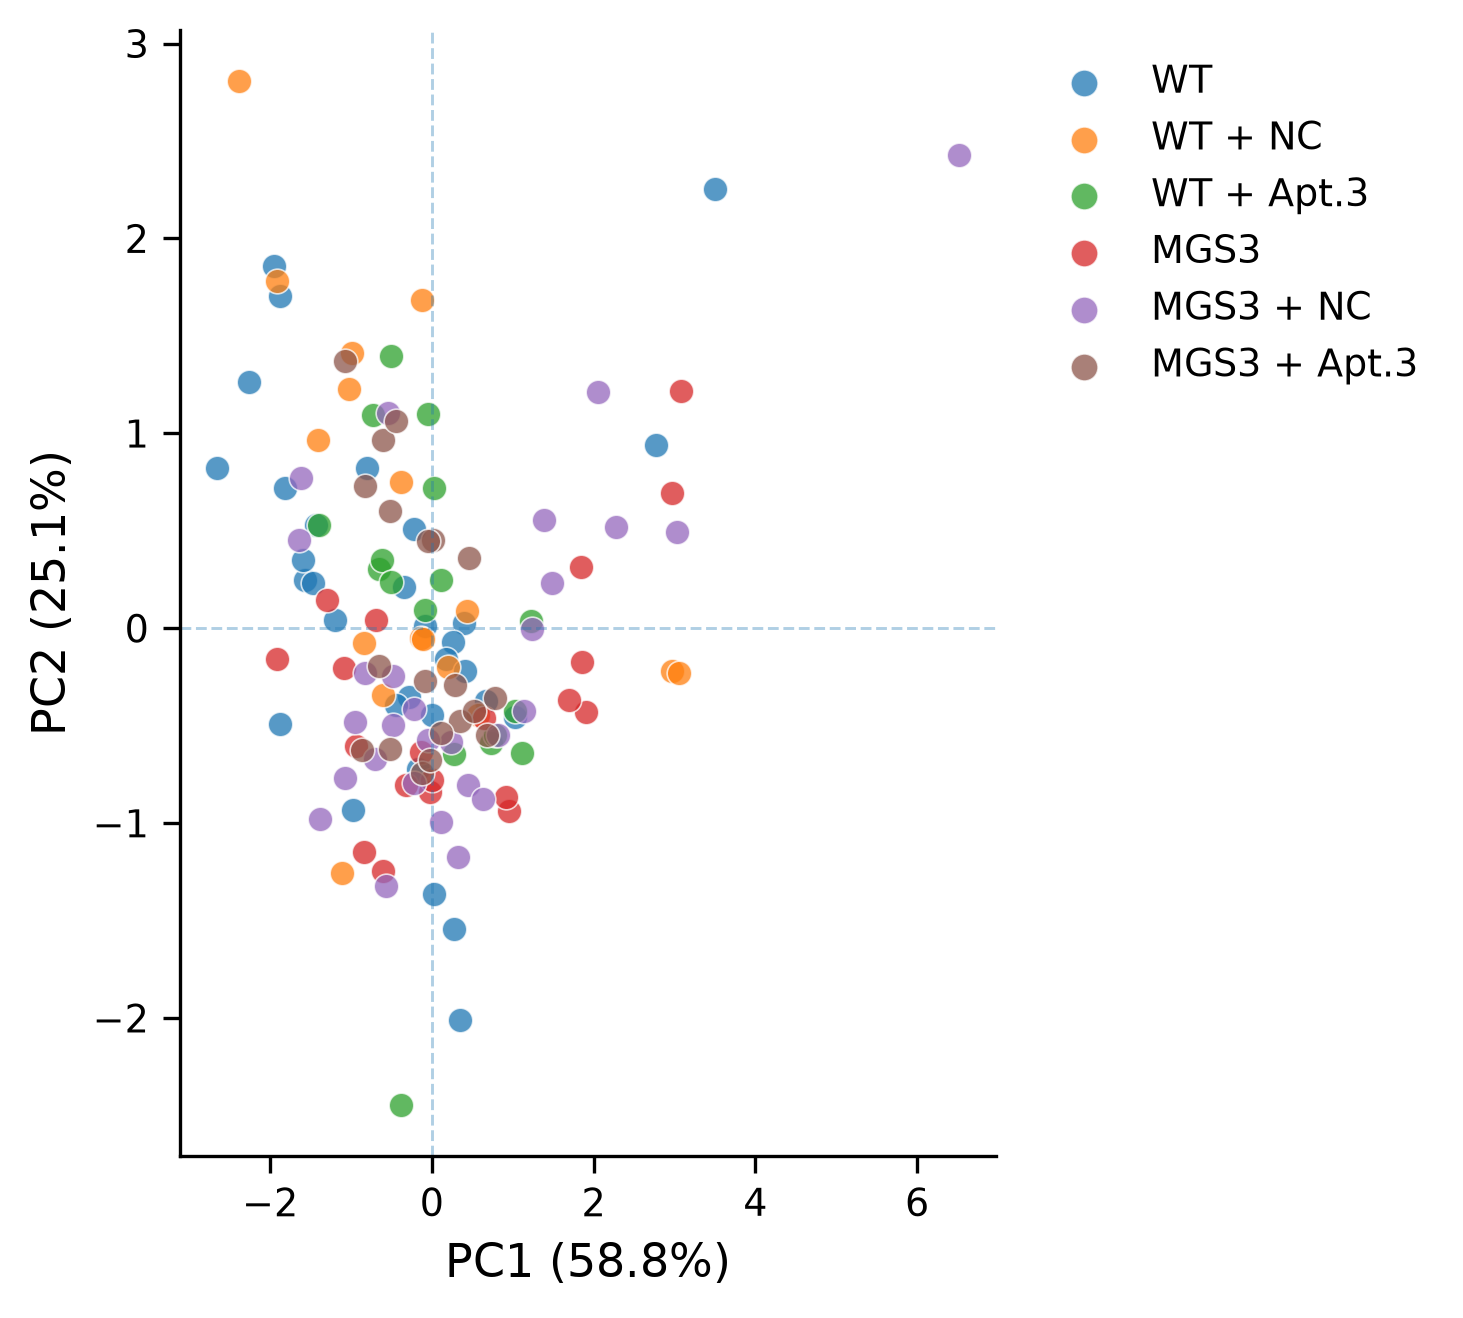

In [4]:
pca_df, pca, fig, ax = pca_from_dataframes(
    df_list=dfs,
    labels=labels,
    columns=[
        "sigma_nm_mean",
        "foci_MFI_mean",
        "n_foci"
    ]
)

# PCs explanation

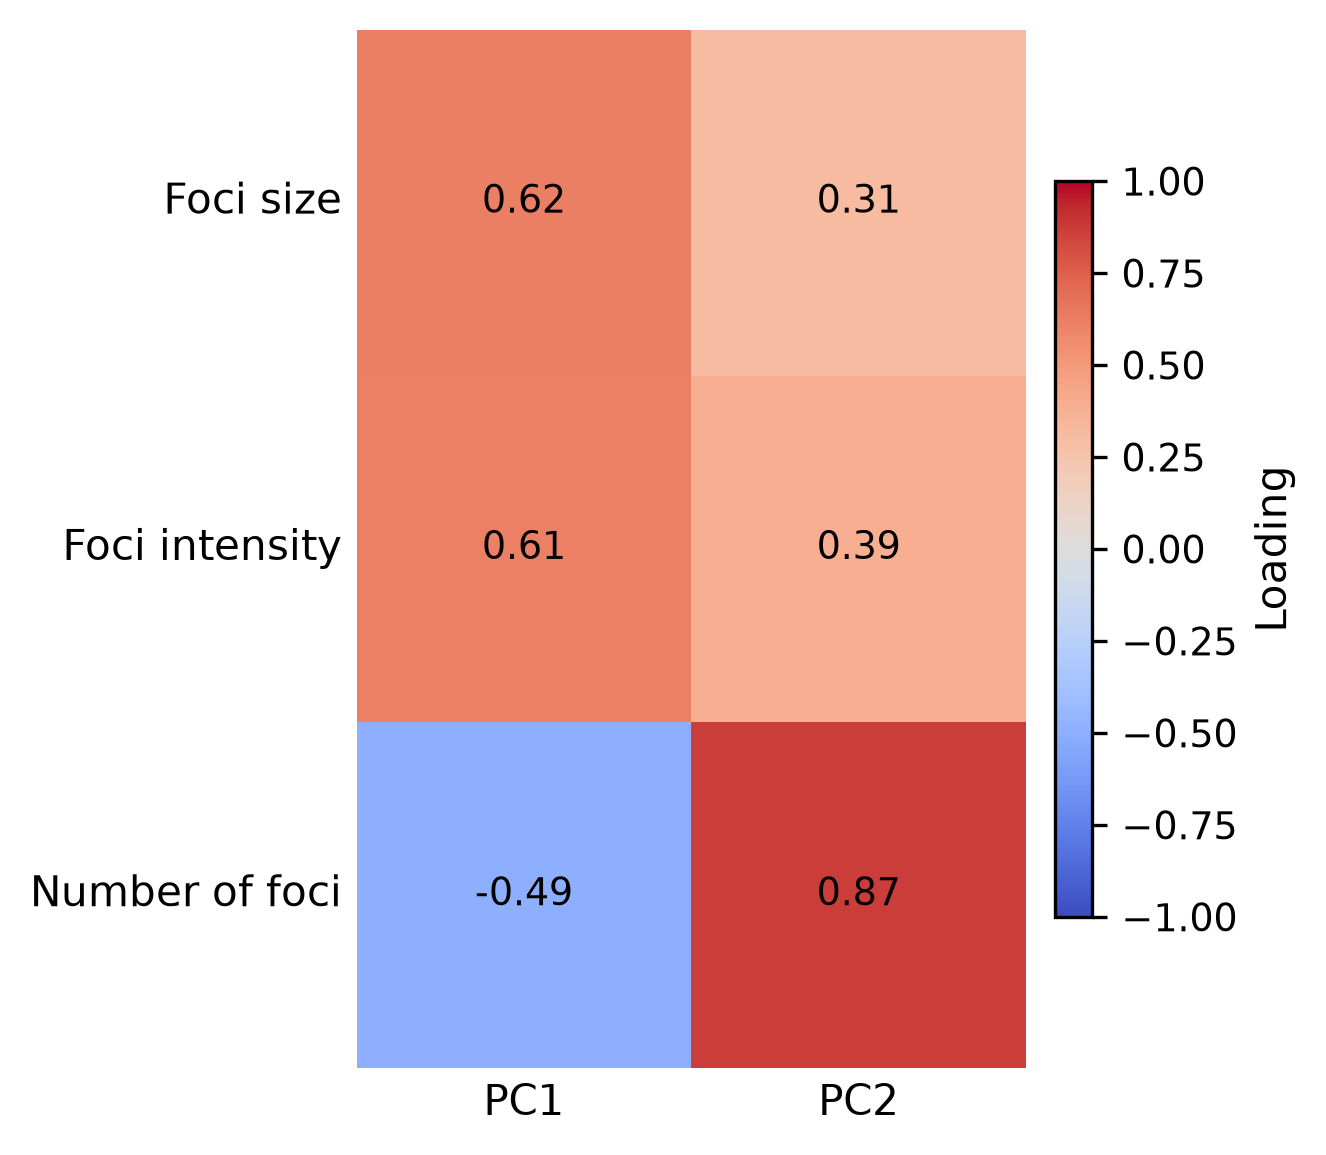

In [5]:
feature_names = {
    "Foci size": "sigma_nm_mean",
    "Foci intensity": "foci_MFI_mean",
    "Number of foci": "n_foci"
}

loadings, fig, ax = plot_pca_loadings(
    pca,
    feature_names
)

# Find center of mass

In [6]:
distances, centroids = pca_centroid_distances(
    pca_df,
    reference="WT"
)

print(distances)

sample
MGS3            0.945623
MGS3 + Apt.3    0.308105
MGS3 + NC       0.855653
WT              0.000000
WT + Apt.3      0.450797
WT + NC         0.416262
Name: distance_from_WT, dtype: float64


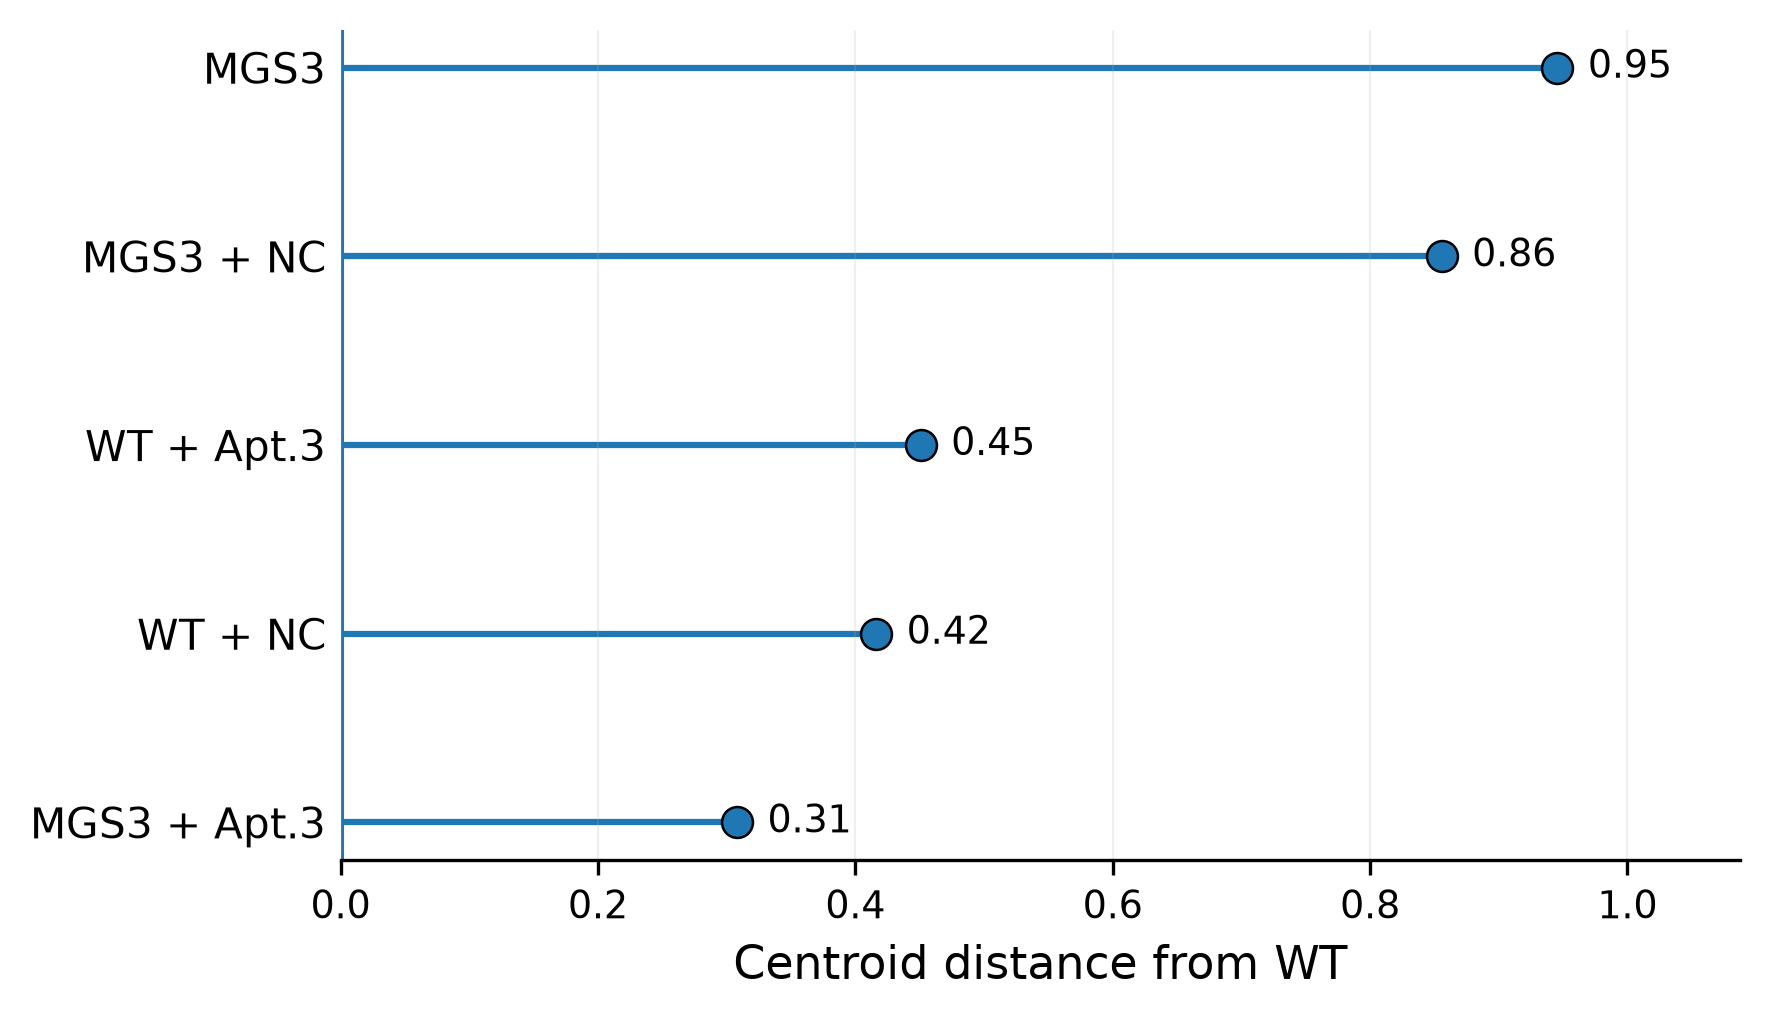

In [7]:
fig, ax = plot_pca_centroid_distances(
    distances,
    reference="WT"
)

# Statistics

### PERMDISP

In [9]:
result = run_permdisp(pca_df)

print(result)

method name               PERMDISP
test statistic name        F-value
sample size                    133
number of groups                 6
test statistic            2.037368
p-value                     0.1739
number of permutations        9999
Name: PERMDISP results, dtype: object


### PERMANOVA

In [11]:
columns = [
    "sigma_nm_mean",
    "foci_MFI_mean",
    "n_foci"
]

stats = pairwise_permanova(
    dfs,
    data,
    columns,
    permutations=9999
)

print(stats)

        group1        group2  n1  n2  pseudo_F  p_value     p_adj  significant
0           WT       WT + NC  31  17  0.730871   0.5264  0.564000        False
1           WT    WT + Apt.3  31  17  1.481898   0.2220  0.333000        False
2           WT          MGS3  31  20  4.959772   0.0079  0.048000         True
3           WT     MGS3 + NC  31  28  3.510696   0.0313  0.117375        False
4           WT  MGS3 + Apt.3  31  20  0.522935   0.6625  0.662500        False
5      WT + NC    WT + Apt.3  17  17  2.562060   0.0462  0.138600        False
6      WT + NC          MGS3  17  20  2.662401   0.0650  0.162500        False
7      WT + NC     MGS3 + NC  17  28  2.292879   0.0954  0.182250        False
8      WT + NC  MGS3 + Apt.3  17  20  1.241689   0.3102  0.409125        False
9   WT + Apt.3          MGS3  17  20  5.465138   0.0029  0.043500         True
10  WT + Apt.3     MGS3 + NC  17  28  2.153918   0.0972  0.182250        False
11  WT + Apt.3  MGS3 + Apt.3  17  20  1.155095   0.3

# Plot with centroids and 95% CI

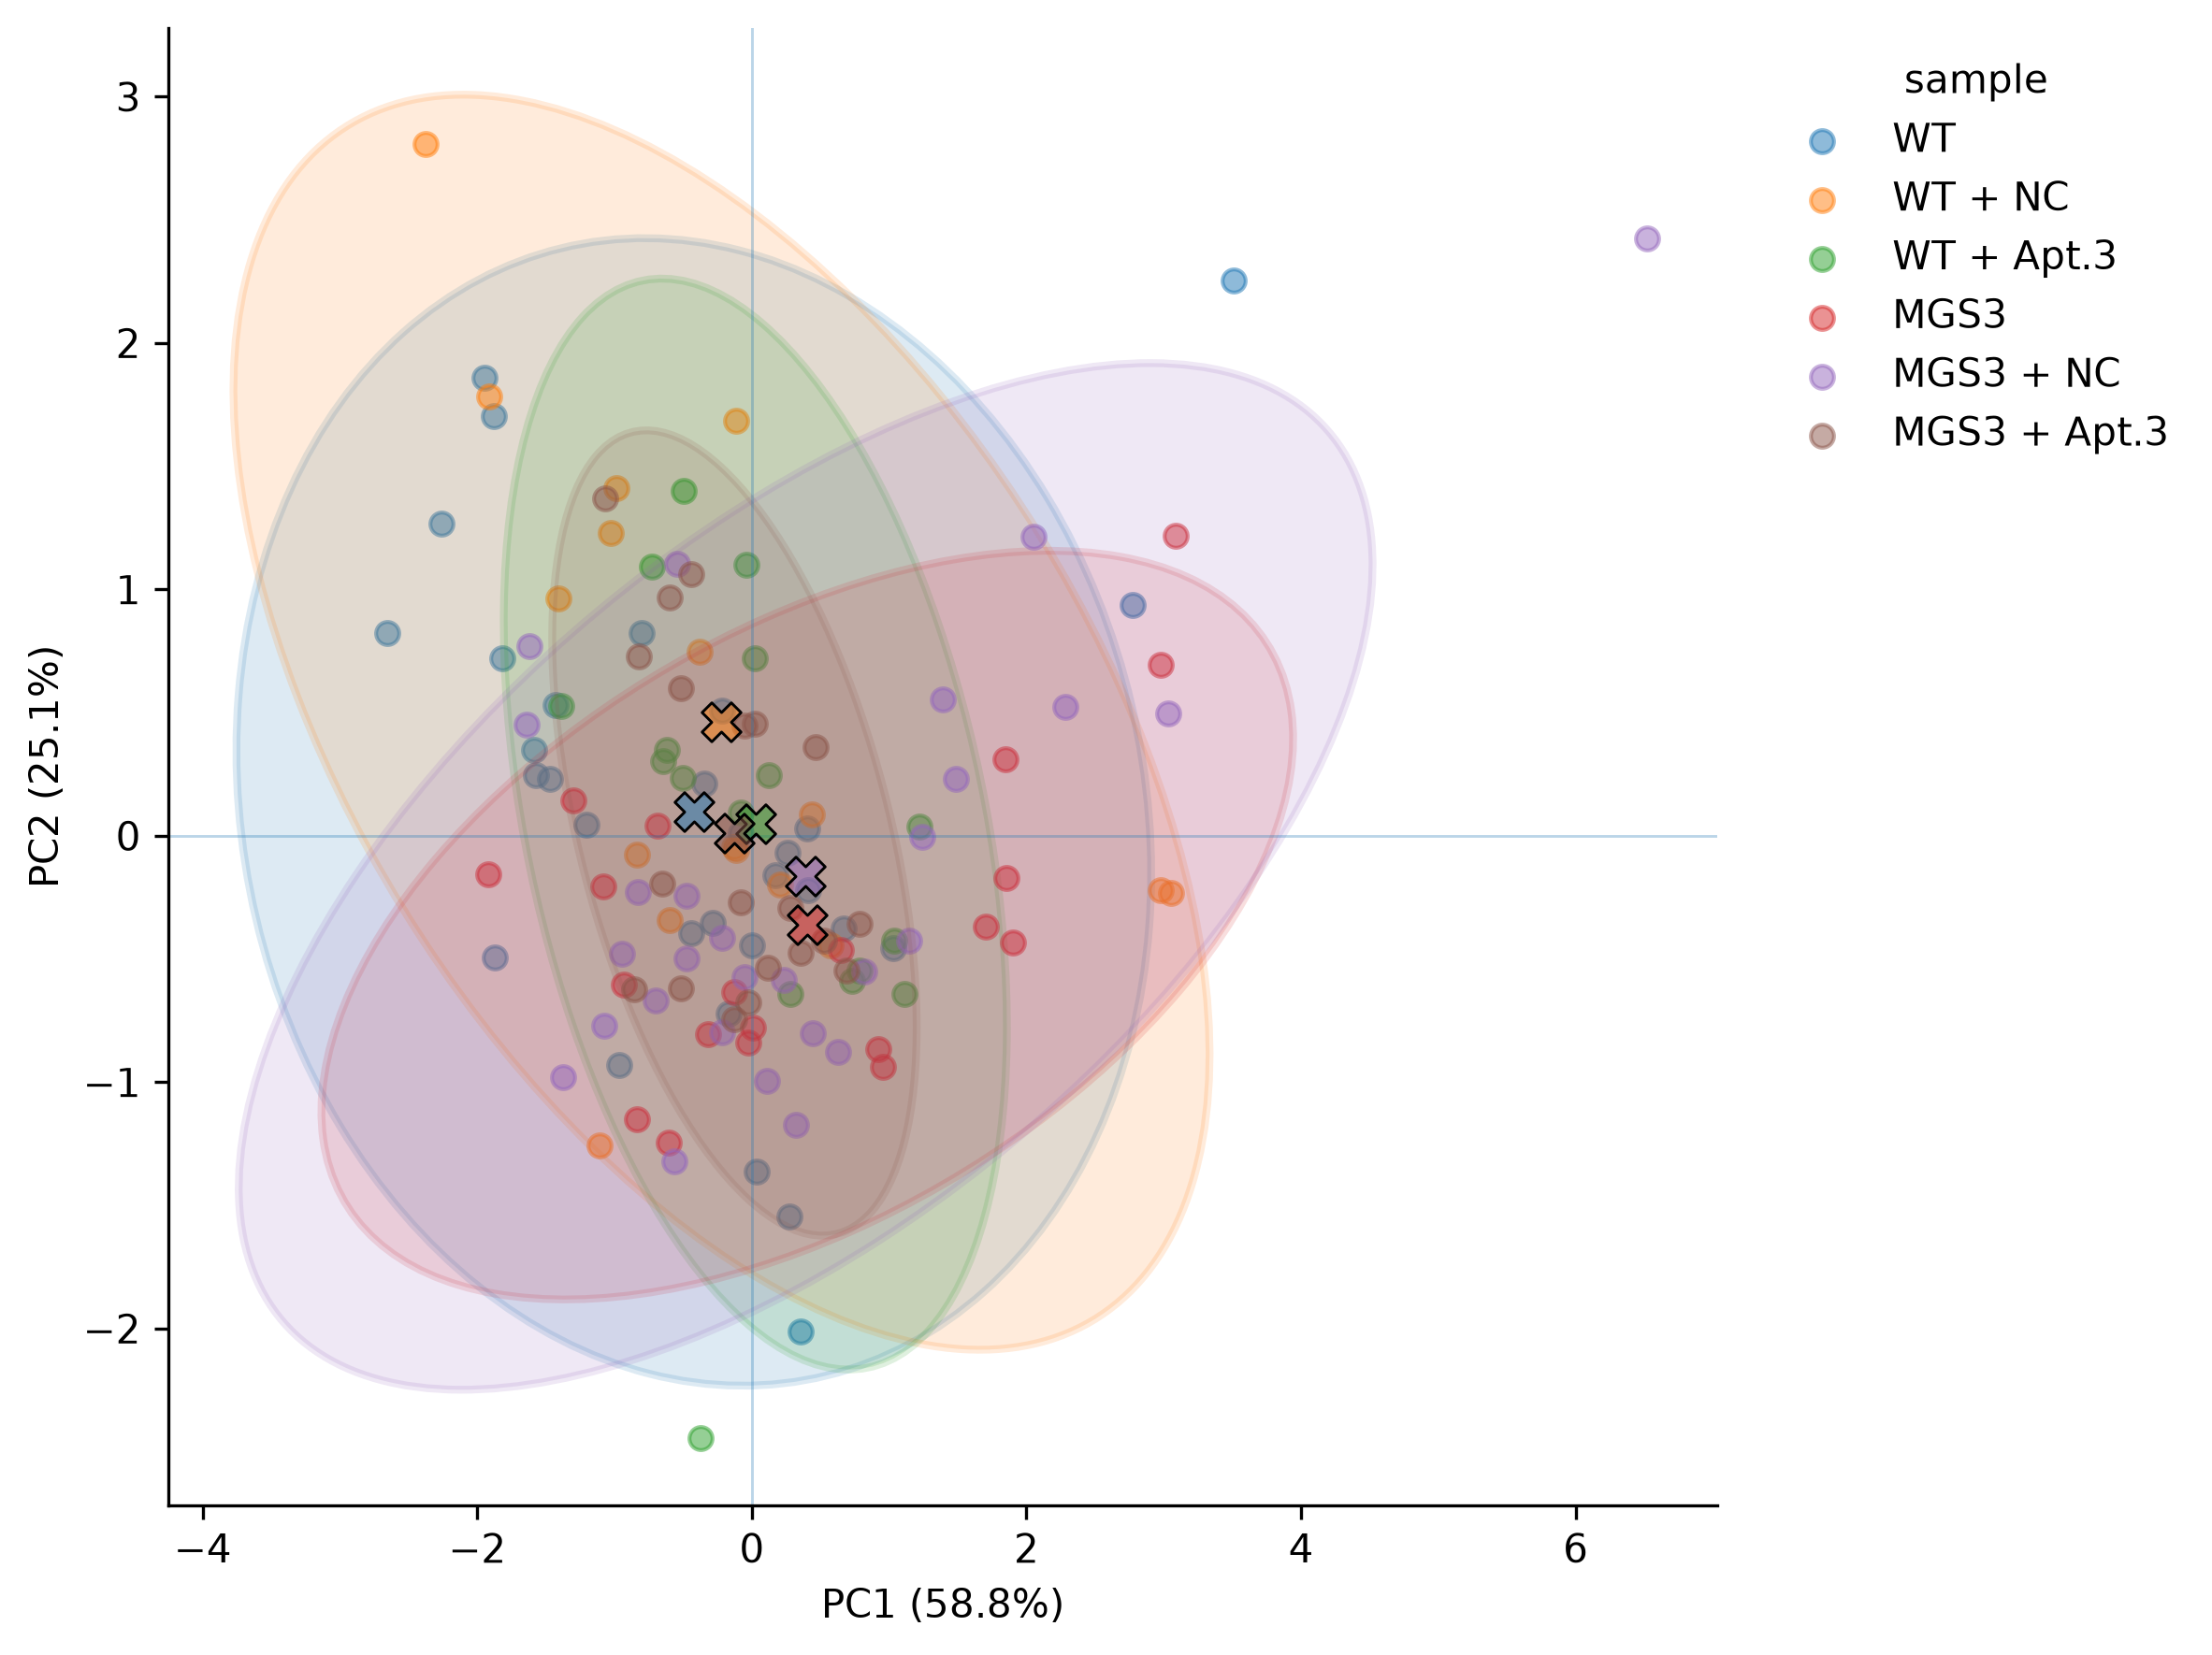

In [13]:
fig, ax = pca_plot_with_ellipse(
    pca_df,
    explained_variance=pca.explained_variance_ratio_
)

plt.show()